## 가설 1 (H1) 분석 - 전쟁 발발 전후 유가 변동 및 시계열 추이 비교
# 분석 개요
가설: 전쟁 발생 이후 국제 유가는 통계적으로 유의미하게 상승한다. 
(전쟁으로 인한 유가 상승 검증) 

사건 (이벤트): 2026-02-28 전쟁 발발 

주요 변수: 

국내_휘발유_가격 

국제_유가_환산가격 (dubai 결측치를 brent로 대체하여 보정)

전쟁 발발일 

## 분석 절차
데이터 전처리 및 대체값 생성: 영문 컬럼명을 직관적인 한글로 매핑하고, 두바이유(dubai)에 결측치가 있을 경우 브렌트유(brent) 데이터로 채워 넣어 연속성 있는 '국제_유가_환산가격' 파생 변수를 생성.

외생변수(Dummy) 할당: 2026년 2월 28일 전쟁 발발일을 기준으로 하여, 이전은 '0', 이후는 '1'을 부여하는 war_shock 변수를 추가해 전/후 데이터를 명확히 분리.

독립표본 t-test 통계 검증: 전쟁 전(pre_war)과 후(post_war)의 '국내 휘발유 가격'을 대상으로 이분산(equal_var=False)을 가정한 독립표본 t-test를 수행하여, 두 기간 간 평균 가격 차이와 통계적 유의성(p-value)을 검증.

단일 원화(₩) 축 시계열 시각화: 이중축이 아닌 단일 축(KRW) 그래프를 생성하여 국제 유가(빨간선)와 국내 유가(파란선)를 같은 단위 선상에서 직접 비교. 전쟁 발발일(2/28)에 기준 수직선과 주석을 추가해 전쟁 발생 이후 국제 유가는 통계적으로 유의미하게 상승함을 보여줌

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

# cursor.execute("DROP TABLE IF EXISTS oil_prices")

cursor.execute("""
CREATE TABLE oil_prices (
    date TEXT,
    dubai REAL,
    brent REAL,
    wti REAL,
    gasoline REAL
)
""")

all_data = [
    ('2026-01-02', 544.41, 548.29, 517.33, 1727.62),
    ('2026-01-05', 528.46, 560.20, 529.00, 1726.61),
    ('2026-01-06', 540.64, 552.38, 519.89, 1725.26),
    ('2026-01-07', 530.05, 545.23, 509.13, 1724.70),
    ('2026-01-08', 531.37, 564.71, 526.17, 1723.51),
    ('2026-01-09', 554.47, 577.44, 538.97, 1721.21),
    ('2026-01-12', 562.19, 584.81, 544.79, 1718.51),
    ('2026-01-13', 568.66, 602.91, 563.13, 1715.74),
    ('2026-01-14', 578.24, 616.22, 574.54, 1713.11),
    ('2026-01-15', 581.20, 592.54, 550.07, 1710.98),
    ('2026-01-16', 576.01, 592.83, 549.48, 1710.16),
    ('2026-01-19', 574.25, 592.61, None, 1708.30),
    ('2026-01-20', 573.00, 601.73, 559.28, 1705.99),
    ('2026-01-21', 579.06, 606.09, 563.17, 1704.20),
    ('2026-01-22', 585.65, 593.44, 549.90, 1702.63),
    ('2026-01-23', 575.31, 608.47, 564.05, 1701.14),
    ('2026-01-26', 586.38, 605.30, 559.53, 1699.39),
    ('2026-01-27', 570.73, 613.20, 566.19, 1698.66),
    ('2026-01-28', 589.14, 623.32, 576.02, 1697.69),
    ('2026-01-29', 596.11, 635.38, 587.85, 1696.20),
    ('2026-01-30', 597.51, 634.49, 585.30, 1694.81),

    ('2026-02-02', 587.20, 599.13, 561.54, 1693.81),
    ('2026-02-03', 596.72, 617.16, 579.40, 1692.91),
    ('2026-02-04', 608.82, 633.06, 593.69, 1692.03),
    ('2026-02-05', 615.40, 616.59, 577.70, 1691.81),
    ('2026-02-06', 623.73, 626.67, 585.23, 1691.46),
    ('2026-02-09', 617.86, 638.48, 595.20, 1690.64),
    ('2026-02-10', 626.21, 633.67, 589.09, 1689.83),
    ('2026-02-11', 628.89, 636.31, 592.58, 1689.26),
    ('2026-02-12', 628.29, 617.67, 574.86, 1688.93),
    ('2026-02-13', 607.19, 615.09, 570.97, 1688.60),
    ('2026-02-16', 608.83, 623.26, None, 1688.43),
    ('2026-02-17', None, 612.09, 565.88, 1688.53),
    ('2026-02-18', None, 638.70, 591.85, 1688.07),
    ('2026-02-19', 636.66, 650.45, 602.98, 1687.54),
    ('2026-02-20', 645.21, 654.79, 605.79, 1687.15),
    ('2026-02-23', 638.22, 651.43, 604.23, 1686.86),
    ('2026-02-24', 639.16, 641.89, 595.27, 1686.30),
    ('2026-02-25', 637.39, 644.30, 594.92, 1686.05),
    ('2026-02-26', 636.74, 638.72, 588.71, 1686.21),
    ('2026-02-27', 638.31, 649.42, 600.50, 1686.05),

    ('2026-03-02', 723.88, 696.55, 638.22, 1686.24),
    ('2026-03-03', 743.41, 734.92, 673.17, 1686.62),
    ('2026-03-04', 795.33, 749.82, 687.73, 1687.33),
    ('2026-03-05', 882.99, 794.44, 753.51, 1687.62),
    ('2026-03-06', 924.90, 853.70, 837.22, 1687.97),
    ('2026-03-09', 1159.31, 917.80, 878.94, 1688.27),
    ('2026-03-10', 1081.90, 824.57, 783.72, 1688.43),
    ('2026-03-11', 1107.49, 852.08, 808.26, 1688.35),
    ('2026-03-12', 1240.40, 927.16, 883.51, 1688.27),
    ('2026-03-13', 1354.38, 960.01, 918.77, 1688.99),
    ('2026-03-16', 1435.68, 938.85, 875.98, 1689.69),
    ('2026-03-17', 1483.54, 973.15, 905.31, 1690.12),
    ('2026-03-18', 1459.38, 1007.44, 903.68, 1690.94),
    ('2026-03-19', 1559.05, 1015.53, 898.60, 1691.40),
    ('2026-03-20', 1498.43, 1058.29, 927.45, 1691.74),
    ('2026-03-23', 1596.13, 939.71, 828.67, 1692.08),
    ('2026-03-24', 1491.04, 992.16, 876.89, 1692.58),
    ('2026-03-25', 1343.42, 963.34, 851.19, 1692.89),
    ('2026-03-26', 1063.39, 1016.07, 888.79, 1695.89),
    ('2026-03-27', 1157.14, 1066.47, 943.98, 1702.07),
    ('2026-03-30', 1188.48, 1069.81, 975.90, 1723.04),
    ('2026-03-31', 1152.77, 1126.59, 965.05, 1777.48),

    ('2026-04-01', 1048.35, 973.84, 963.83, 1834.28),
    ('2026-04-02', 1086.86, 1034.03, 1057.84, 1871.82),
    ('2026-04-06', 1139.82, 1040.91, 1065.95, 1889.40),
    ('2026-04-07', 1155.25, 1035.90, 1070.78, 1895.32),
    ('2026-04-08', 959.14, 898.01, 894.78, 1902.67),
    ('2026-04-09', 947.02, 890.57, 908.68, 1906.95),
    ('2026-04-10', 939.70, 886.88, 899.64, 1904.28),
    ('2026-04-13', 991.28, 924.82, 922.22, 1898.78),
    ('2026-04-14', 966.87, 888.25, 855.36, 1864.07),
    ('2026-04-15', 941.94, 884.55, 850.63, 1845.31),
    ('2026-04-16', 943.24, 920.91, 877.37, 1840.09),
    ('2026-04-17', 946.63, 837.15, 776.66, 1832.70),
    ('2026-04-20', 916.94, 888.83, 834.18, 1827.50),
    ('2026-04-21', 874.96, 914.03, 855.09, 1824.35),
    ('2026-04-22', 928.82, 942.79, 859.99, 1822.05),
    ('2026-04-23', 974.10, 976.52, 890.83, 1820.38),
    ('2026-04-24', 998.34, 980.92, 879.13, 1819.83),
    ('2026-04-27', 971.91, 1009.49, 898.87, 1819.66),
    ('2026-04-28', 993.28, 1030.90, 925.92, 1819.26),
    ('2026-04-29', 986.83, 1093.78, 990.45, 1818.92),
    ('2026-04-30', 1041.73, 1058.53, 975.53, 1818.94),

    ('2026-05-01', None, 1004.31, 946.47, 1819.35),
    ('2026-05-04', 960.45, 1068.79, 993.88, 1838.79),
    ('2026-05-05', 995.56, 1026.10, 955.13, 1855.86),
    ('2026-05-06', 959.06, 936.68, 879.42, 1864.76),
    ('2026-05-07', 894.23, 916.86, 868.76, 1881.09),
    ('2026-05-08', 888.72, 924.31, 870.75, 1894.96),
    ('2026-05-11', 932.34, 960.92, 904.30, 1909.78),
    ('2026-05-12', 971.90, 998.49, 946.70, 1921.28),
    ('2026-05-13', 979.36, 986.17, 943.13, 1931.84),
    ('2026-05-14', 992.13, 994.20, 951.41, 1942.44),
    ('2026-05-15', 1006.83, 1025.22, 989.19, 1948.40),
    ('2026-05-18', 1017.79, 1057.51, 1025.06, 1958.37),
    ('2026-05-19', 1009.93, 1052.29, 1019.10, 1968.38),
    ('2026-05-20', 1008.30, 993.36, 929.42, 1977.77),
    ('2026-05-21', 984.72, 974.09, 914.93, 1984.96),
    ('2026-05-22', 983.61, 979.17, 913.53, 1988.93),
    ('2026-05-25', 927.62, 909.18, None, 1991.54),
    ('2026-05-26', 932.91, 947.85, 893.69, 1992.69),
    ('2026-05-27', None, 894.30, 841.09, 1994.92),
    ('2026-05-28', 937.03, 885.08, 839.65, 1996.72),
]

cursor.executemany("""
INSERT INTO oil_prices (date, dubai, brent, wti, gasoline)
VALUES (?, ?, ?, ?, ?)
""", all_data)
conn.commit()

query = """
SELECT *
FROM oil_prices
ORDER BY date
"""

df = pd.read_sql_query(query, conn)

print(df)

           date   dubai   brent     wti  gasoline
0    2026-01-02  544.41  548.29  517.33   1727.62
1    2026-01-05  528.46  560.20  529.00   1726.61
2    2026-01-06  540.64  552.38  519.89   1725.26
3    2026-01-07  530.05  545.23  509.13   1724.70
4    2026-01-08  531.37  564.71  526.17   1723.51
..          ...     ...     ...     ...       ...
99   2026-05-22  983.61  979.17  913.53   1988.93
100  2026-05-25  927.62  909.18     NaN   1991.54
101  2026-05-26  932.91  947.85  893.69   1992.69
102  2026-05-27     NaN  894.30  841.09   1994.92
103  2026-05-28  937.03  885.08  839.65   1996.72

[104 rows x 5 columns]


## H1 가설 분석 

=== [1] 변수 매핑 기반 가설 1 t-test 결과 ===
전쟁 전 국내 휘발유 가격 평균: 1700.17 원/L
전쟁 후 국내 휘발유 가격 평균: 1822.97 원/L
t-통계량: -9.0011 || 유의확률(p-value): 0.0000



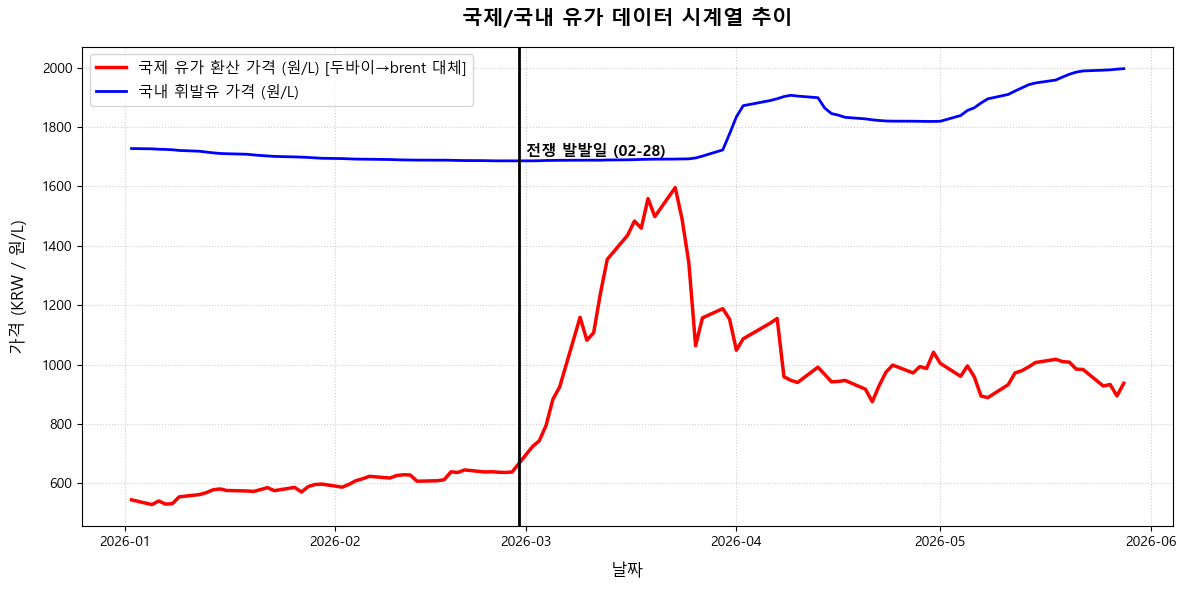

In [6]:

# =====================================================================
# [수정된 부분] 
# 하단 분석 코드에 맞도록 영문 컬럼을 한글로 매핑하고 파생 변수(대체값)를 생성합니다.
# =====================================================================
df = df.rename(columns={'date': '날짜', 'gasoline': '국내_휘발유_가격'})
# 두바이유가 결측치일 경우 브렌트유로 채워 '국제_유가_환산가격' 컬럼 생성
df['국제_유가_환산가격'] = df['dubai'].fillna(df['brent'])


# 한글 폰트 설정 (필요 시 환경에 맞게 수정)
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # macOS
plt.rcParams['axes.unicode_minus'] = False


# === [전처리] 시계열 정렬 및 연속화 인덱스 확보 ===
df['날짜'] = pd.to_datetime(df['날짜'])
df = df.sort_values('날짜').reset_index(drop=True)

# 외생변수 (War Shock Dummy: 전쟁 발발일인 2/28 이후는 1, 이전은 0)
df['war_shock'] = np.where(df['날짜'] >= '2026-02-28', 1, 0)


# === [분석 1] 독립표본 t-test (국내 휘발유 가격 기준) ===
pre_war  = df[df['날짜'] < '2026-02-28']
post_war = df[df['날짜'] >= '2026-02-28']

t_stat, p_val = stats.ttest_ind(
    pre_war['국내_휘발유_가격'].dropna(),
    post_war['국내_휘발유_가격'].dropna(),
    equal_var=False
)

print("=== [1] 변수 매핑 기반 가설 1 t-test 결과 ===")
print(f"전쟁 전 국내 휘발유 가격 평균: {pre_war['국내_휘발유_가격'].mean():.2f} 원/L")
print(f"전쟁 후 국내 휘발유 가격 평균: {post_war['국내_휘발유_가격'].mean():.2f} 원/L")
print(f"t-통계량: {t_stat:.4f} || 유의확률(p-value): {p_val:.4f}\n")


# === [분석 3] 단일 원화(₩) 축 기반 시각화 ===
fig, ax = plt.subplots(figsize=(12, 6))

line1 = ax.plot(
    df['날짜'], df['국제_유가_환산가격'],
     color='red', linewidth=2.5,
    label='국제 유가 환산 가격 (원/L) [두바이→brent 대체]'
)
line2 = ax.plot(
    df['날짜'], df['국내_휘발유_가격'],
     color='blue', linewidth=2,
    label='국내 휘발유 가격 (원/L)'
)

ax.set_xlabel('날짜', fontsize=12, labelpad=10)
ax.set_ylabel('가격 (KRW / 원/L)', fontsize=12, labelpad=10)
ax.grid(True, linestyle=':', alpha=0.6)

# 전쟁 발발 기준 수직선 (2026-02-28)
ax.axvline(pd.to_datetime('2026-02-28'), color='black', linestyle='-', linewidth=2)

# y축 텍스트 위치: gasoline 최솟값 근처에 배치
y_annot = df['국내_휘발유_가격'].min() * 1.01
ax.text(
    pd.to_datetime('2026-02-28') + pd.Timedelta(days=1),
    y_annot,
    '전쟁 발발일 (02-28)',
    color='black', fontsize=11, fontweight='bold'
)

lines  = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('국제/국내 유가 데이터 시계열 추이', fontsize=15, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

1. t-검정(t-test) 통계 결과 해석
전쟁 발발일(2월 28일)을 기점으로 국내 휘발유 가격에 통계적으로 유의미한 변화가 있었는지 검증한 결과입니다.

평균 가격 상승: 전쟁 전 평균 1700.17원/L에서 전쟁 후 1822.97원/L로 약 122.8원 상승했습니다.

통계적 유의성 (p-value): 유의확률(p-value)이 0.0000으로 산출되었습니다. 이는 통상적인 유의수준(0.05 또는 0.01)보다 훨씬 작으므로, "전쟁 발발 전후의 국내 휘발유 가격 상승은 통계적으로 매우 유의미하다"고 결론 내릴 수 있습니다. 즉, 우연에 의한 가격 변동이 아니라 전쟁이라는 외부 충격(Shock)이 가격 상승을 견인했음을 통계적으로 뒷받침합니다.


2. 시계열 그래프 시각적 흐름 해석 (국제 유가 vs 국내 유가)
빨간선(국제 유가 환산 가격)과 파란선(국내 휘발유 가격)의 추이를 비교해 보면, 에너지 시장의 전형적인 특징 두 가지가 매우 잘 드러납니다.

반응 시차 (Lagging Effect):

2월 28일 전쟁 발발 직후, 국제 유가(빨간선)는 즉각적이고 가파르게 급등하여 3월 중순 최고점을 찍습니다.

반면 국내 휘발유 가격(파란선) 역시 3월 초부터 상승하지만, 국제 유가에 비해 약간의 시차(Lag)를 두고 뒤따라 오르는 모습을 보입니다. 이는 원유 수입부터 정제, 국내 주유소 유통까지 걸리는 물리적 시간(보통 2~3주)이 차트에 반영된 결과입니다.

가격 반영의 비대칭성 (Rockets and Feathers 효과):

3월 중순 이후 국제 유가는 고점을 찍고 급격히 하락하여 4월부터는 다시 900원~1000원대 박스권으로 하락 안정화되는 추세를 보입니다.

하지만 국내 휘발유 가격은 국제 유가의 하락세를 전혀 따라가지 않고 높은 수준(1800원~2000원대)을 계속 유지하며 오히려 완만하게 우상향하고 있습니다.

이는 유가가 오를 때는 쏜살같이(로켓처럼) 올리고 내릴 때는 천천히(깃털처럼) 내린다는 주유소 시장의 비대칭적 가격 반영 현상을 시각적으로 뚜렷하게 보여줍니다. (여기에는 정유사 마진 방어뿐만 아니라 환율 상승, 유류세 변동 등 복합적인 요인이 섞여 있을 수 있습니다.)